In [ ]:
#STEP 1st----- Get Data
import pandas as pd
df= pd.read_csv("netflix_titles.csv.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
#Information about Data
df.shape #Row and columns in dataset
df.columns #columns names
df.info() #columns name and their datatypes

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [ ]:
#STEP 2nd-----Data Cleaning
df.isnull().sum() #using for checking missing values

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [ ]:
#STEP 3rd------fill missing values/Handle missing values
columns=['director','cast','country','rating']
for col in columns:
    df[col]= df[col].fillna('unknown')
#checking missing values
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64

In [17]:
# STEP 4TH-----convert date_added to date_format
df['date_added']= pd.to_datetime(df['date_added'], errors='coerce')             #df['date_added']= date added column of dataframe
df['date_added'].head()                                                         #pd.to_datetime()= python, converts text_dates into date format(i.e.20-03-23)
                                                                                #error="coerce"== dont give errors if any date is invalid or missing


0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

In [18]:
#STEP 5th----- Check Duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
#Project Topic 1-------"Movie vs TV Shows Analysis"
#PART 1----Pandas Analysis
df['type'].value_counts()     #Counts the value of Movies and TV Shows

In [ ]:
%pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns                        #Data Visualization Library #Advanced Version Of Matplotlib
import matplotlib.pyplot as plt              #Base Plotting Library

print('Sucessfully Installed!!!!!')

Sucessfully Installed!!!!!


In [2]:
df=pd.read_csv('netflix_titles.csv.csv')

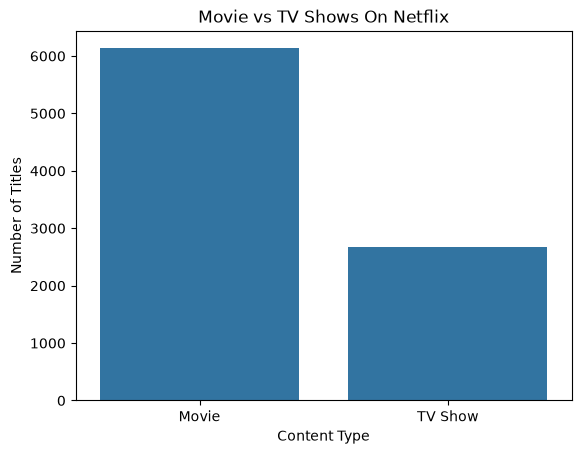

In [24]:
#Project Topic 1-------"Movie vs TV Shows Analysis"
#PART 2--- Seaborn Visualization


plt.Figure(figsize=(6,4))         #ChartSize

sns.countplot(data=df, x='type')

plt.title('Movie vs TV Shows On Netflix')   #Title of Chart
plt.xlabel('Content Type')                  #X-axis Label
plt.ylabel('Number of Titles')              #Y-axis Label

plt.show()                                  #Displays Chart

In [ ]:
#Project Topic 2-----------Content By Country (split → stack → strip → value_counts method)
df['country'].head(10)
df['country'].value_counts()

In [ ]:
#content by country  -----split countries
country_data=df['country'].str.split(',', expand=True)
country_data.head()
country_data= country_data.stack()                     #Stack converts all separate country columns into one long series.


In [ ]:
#Content By Country
country_split=df['country'].str.split(',', expand=True)
country_split.head()

In [ ]:
#Content By Country
country_list= country_split.stack()                     ##Stack converts all separate country columns into one long series.
country_list.head(10)


0  0    United States
   1              NaN
   2              NaN
   3              NaN
   4              NaN
   5              NaN
   6              NaN
   7              NaN
   8              NaN
   9              NaN
dtype: str

In [ ]:
#Stack
country_list= country_split.stack()
country_list.head(20)

In [ ]:
#Strip & Value Counts
country_list= country_list.str.strip()                               #strip() uses for remove extra space.
country_count = country_list.value_counts()                          #Giving more cleaner and accurate country counts.

country_count.head(10)

United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

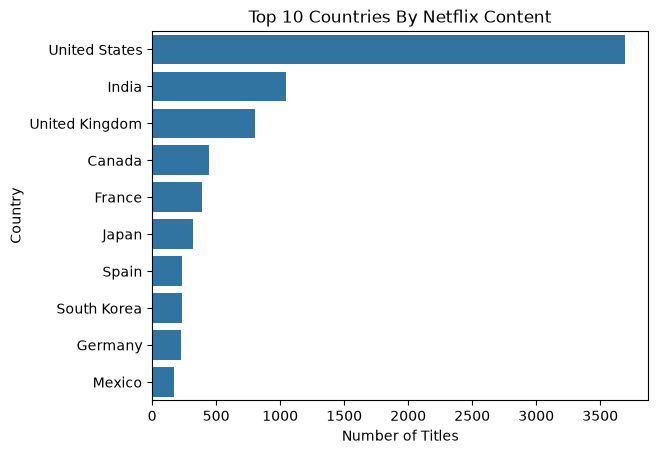

In [25]:
#Seaborn Visualization
country_count=country_list.str.strip().value_counts().head(10)

plt.Figure(figsize=(10,6))
sns.barplot(x=country_count.values, y=country_count.index)

plt.title('Top 10 Countries By Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

In [ ]:
#Project 3-------"Genre Analysis"
# What genres are most common on Netflix?
# Split
genre_split= df['listed_in'].str.split(',', expand= True)
genre_split.head()

,0,1,2
0,Documentaries,NaN,NaN
1,International TV Shows,TV Dramas,TV Mysteries
2,Crime TV Shows,International TV Shows,TV Action & Adventure
3,Docuseries,Reality TV,NaN
4,International TV Shows,Romantic TV Shows,TV Comedies


In [27]:
#stack
genre_list= genre_split.stack()
genre_list.head(10)

0  0              Documentaries
   1                        NaN
   2                        NaN
1  0     International TV Shows
   1                  TV Dramas
   2               TV Mysteries
2  0             Crime TV Shows
   1     International TV Shows
   2      TV Action & Adventure
3  0                 Docuseries
dtype: str

In [ ]:
#strip
genre_list=genre_list.str.strip()

In [30]:
#value_count
genre_count=genre_list.value_counts()
genre_count.head(10)

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [31]:
#Content Rating Analysis
# Which content ratings are most common on netflix?
#count the ratings
rating_count= df['rating'].value_counts()
rating_count.head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

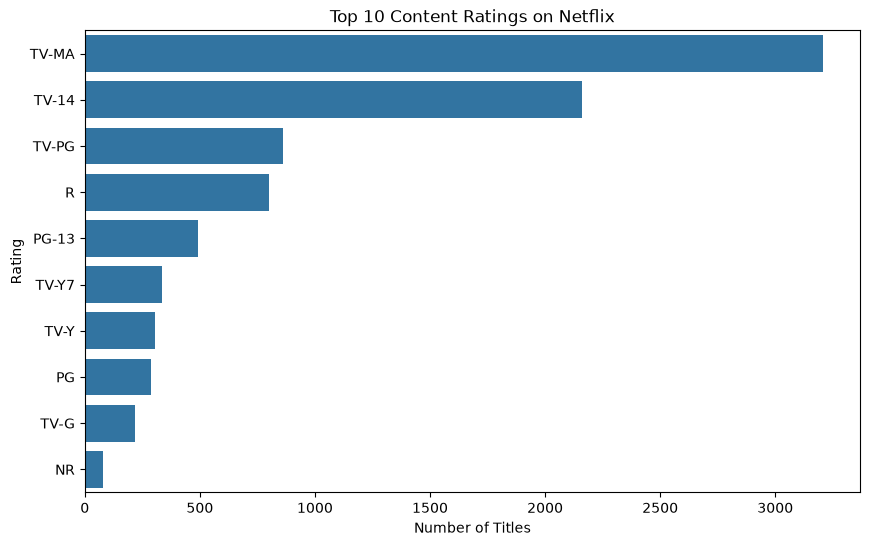

In [32]:
#visualization
rating_count= df['rating'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=rating_count.values, y=rating_count.index)

plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.show()


In [ ]:
#Project 4------- Year-Wise Content Growth
year_count = df['release_year'].value_counts().sort_index()                          #sort_index= put the years in chronological order
year_count

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

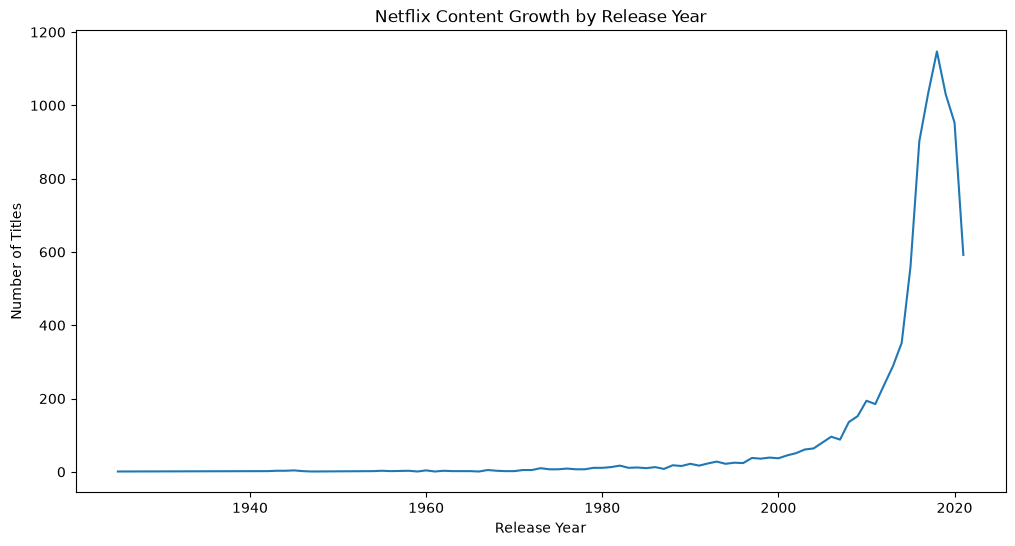

In [34]:
# Visualization
plt.figure(figsize=(12,6))

sns.lineplot(x=year_count.index, y=year_count.values)

plt.title('Netflix Content Growth by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.show()